# CSL7110 Assignment 3  
## Recommender Systems: Content-Based and Collaborative Filtering

**Name:** Ashish Sinha  
**Roll No:** M25DE1047

## Setup and Imports

In [1]:
# Install required packages (run once)
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import subprocess, sys
import math
import random
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Spark
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import DoubleType, ArrayType, FloatType
from pyspark.storagelevel import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.linalg import DenseVector, SparseVector
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

# sklearn — Task 1 explicitly requires TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import shap

from surprise import SVD, Dataset, Reader
from surprise.model_selection import (
    train_test_split as surprise_split,
    GridSearchCV as SurpriseGridSearch,
)
from surprise import accuracy as surprise_accuracy

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

/Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Spark Session Configuration

In [3]:
spark = (
    SparkSession.builder
    .appName("CSL7110_Assignment3")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.default.parallelism", "64")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/21 22:51:34 WARN Utils: Your hostname, ASHISHs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.6 instead (on interface en0)
26/03/21 22:51:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/21 22:51:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/21 22:51:35 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1


## Dataset Configuration

In [4]:
project_root = Path.cwd().resolve().parent
BASE_DIR = project_root / "dataset" / "ml-latest-small"
MOVIES_FILE  = f"file://{(BASE_DIR / 'movies.csv').resolve()}"
RATINGS_FILE = f"file://{(BASE_DIR / 'ratings.csv').resolve()}"

TOP_K             = 5
POSITIVE_THRESHOLD = 4.0

# Memory-safety knobs (adjust if you have more RAM)
MAX_EVAL_USERS   = 100
MAX_CF_USERS     = 800
MAX_CF_MOVIES    = 1200
MAX_LOCAL_MOVIES = 5000
MAX_LOCAL_RATINGS = 150000
MAX_NEURAL_ROWS  = 80000

print("Movies path :", MOVIES_FILE)
print("Ratings path:", RATINGS_FILE)

Movies path : file:///Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/dataset/ml-latest-small/movies.csv
Ratings path: file:///Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/dataset/ml-latest-small/ratings.csv


## Load Dataset with Spark

In [5]:
movies_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(MOVIES_FILE)
)

ratings_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(RATINGS_FILE)
)

print("Movies rows :", movies_raw.count())
print("Ratings rows:", ratings_raw.count())

movies_raw.show(5, truncate=False)
ratings_raw.show(5, truncate=False)

Movies rows : 9742
Ratings rows: 100836
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
+-------+----------------------------------+-------------------------------------------+
only showing top 5 rows
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|

## Preprocessing

In [6]:
# ── Clean genres and extract release year from title ──────────────────────────
movies = (
    movies_raw
    .withColumn(
        "genres_clean",
        F.when(
            F.col("genres").isNull() | (F.col("genres") == "(no genres listed)"),
            F.lit("Unknown")
        ).otherwise(F.col("genres"))
    )
    .withColumn(
        "year",
        F.when(
            F.col("title").rlike(r"\((\d{4})\)\s*$"),
            F.regexp_extract(F.col("title"), r"\((\d{4})\)\s*$", 1).cast("int")
        ).otherwise(F.lit(None).cast("int"))
    )
)

# ── Per-movie and per-user aggregate statistics ────────────────────────────────
movie_stats = (
    ratings_raw
    .groupBy("movieId")
    .agg(
        F.count("*").alias("movie_rating_count"),
        F.avg("rating").alias("movie_avg_rating")
    )
)

user_stats = (
    ratings_raw
    .groupBy("userId")
    .agg(
        F.count("*").alias("user_rating_count"),
        F.avg("rating").alias("user_avg_rating")
    )
)

global_mean_rating = ratings_raw.agg(F.avg("rating").alias("avg")).first()["avg"]

movies = (
    movies.join(movie_stats, on="movieId", how="left")
    .fillna({
        "movie_rating_count": 0,
        "movie_avg_rating": float(global_mean_rating)
    })
)

movies.persist(StorageLevel.MEMORY_AND_DISK)
user_stats.persist(StorageLevel.MEMORY_AND_DISK)

movies.show(5, truncate=False)

+-------+----------------------------------+-------------------------------------------+-------------------------------------------+----+------------------+------------------+
|movieId|title                             |genres                                     |genres_clean                               |year|movie_rating_count|movie_avg_rating  |
+-------+----------------------------------+-------------------------------------------+-------------------------------------------+----+------------------+------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|Adventure|Animation|Children|Comedy|Fantasy|1995|215               |3.9209302325581397|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |Adventure|Children|Fantasy                 |1995|110               |3.4318181818181817|
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |Comedy|Romance                  

In [7]:
# ── 80/20 random split; ensure test users and movies exist in train ────────────
train_ratings, test_ratings = ratings_raw.randomSplit([0.8, 0.2], seed=42)

train_users  = train_ratings.select("userId").distinct()
train_movies = train_ratings.select("movieId").distinct()

test_ratings_in_train = (
    test_ratings
    .join(train_users,  on="userId",  how="inner")
    .join(train_movies, on="movieId", how="inner")
)

print("Train ratings         :", train_ratings.count())
print("Test ratings          :", test_ratings.count())
print("Filtered test ratings :", test_ratings_in_train.count())

Train ratings         : 80578
Test ratings          : 20258
Filtered test ratings : 19437


## Common Helper Functions

In [8]:
def precision_recall_at_k(recommended_ids, relevant_ids, k=5):
    """Compute Precision@K and Recall@K given ranked recommendation list."""
    recommended_top_k = list(recommended_ids)[:k]
    relevant_set = set(relevant_ids)
    hits = len(set(recommended_top_k) & relevant_set)
    precision = hits / k if k > 0 else 0.0
    recall    = hits / len(relevant_set) if len(relevant_set) > 0 else 0.0
    return precision, recall


def rmse_score(y_true, y_pred):
    """Root Mean Squared Error between two lists."""
    if len(y_true) == 0:
        return float("nan")
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def clip_rating(x, low=0.5, high=5.0):
    return float(np.clip(x, low, high))


def to_numpy(v):
    """Convert a Spark ML Vector (sparse or dense) to a NumPy array."""
    if isinstance(v, SparseVector):
        return v.toArray()
    if isinstance(v, DenseVector):
        return np.array(v)
    return np.array(v)

In [9]:
# ── Pre-compute seen movies and ground-truth relevant movies for eval users ────
train_seen_movies_pd = (
    train_ratings.groupBy("userId")
    .agg(F.collect_set("movieId").alias("seen_movies"))
    .toPandas()
)
train_seen_movies = dict(zip(
    train_seen_movies_pd["userId"],
    train_seen_movies_pd["seen_movies"]
))

relevant_test_pd = (
    test_ratings_in_train
    .filter(F.col("rating") >= POSITIVE_THRESHOLD)
    .groupBy("userId")
    .agg(F.collect_list("movieId").alias("relevant_movies"))
    .orderBy(F.desc(F.size("relevant_movies")))
    .limit(MAX_EVAL_USERS)
    .toPandas()
)
relevant_test_items = dict(zip(
    relevant_test_pd["userId"],
    relevant_test_pd["relevant_movies"]
))
eval_users = list(relevant_test_items.keys())

print(f"Evaluation users: {len(eval_users)}")

Evaluation users: 100


---
# Part 1: Content-Based Filtering

## Task 1: TF-IDF Based Recommendation Using Movie Genres

In [10]:
# ── Step 1: Collect movie genres from Spark ─────────────────────────────────
movies_local_pd = (
    movies
    .select("movieId", "title", "genres_clean", "year",
            "movie_rating_count", "movie_avg_rating")
    .toPandas()
)

# Replace pipe separators with spaces so each genre becomes a token
# e.g. 'Action|Sci-Fi' -> 'Action Sci-Fi'
movies_local_pd["genre_str"] = (
    movies_local_pd["genres_clean"]
    .str.replace("|", " ", regex=False)
    .fillna("Unknown")
)

print(f"Total movies loaded: {len(movies_local_pd)}")
movies_local_pd[["movieId", "title", "genre_str"]].head()

Total movies loaded: 9742


,movieId,title,genre_str
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


In [11]:
# ── Step 2: Compute TF-IDF vectors using TfidfVectorizer from sklearn ────────
# token_pattern includes hyphens to keep genres like 'Sci-Fi' as one token
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r"[A-Za-z\-]+",
    min_df=1,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(movies_local_pd["genre_str"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary        :", sorted(tfidf_vectorizer.vocabulary_.keys()))

TF-IDF matrix shape: (9742, 20)
Vocabulary        : ['action', 'adventure', 'animation', 'children', 'comedy', 'crime', 'documentary', 'drama', 'fantasy', 'film-noir', 'horror', 'imax', 'musical', 'mystery', 'romance', 'sci-fi', 'thriller', 'unknown', 'war', 'western']


Cosine similarity matrix shape: (9742, 9742)


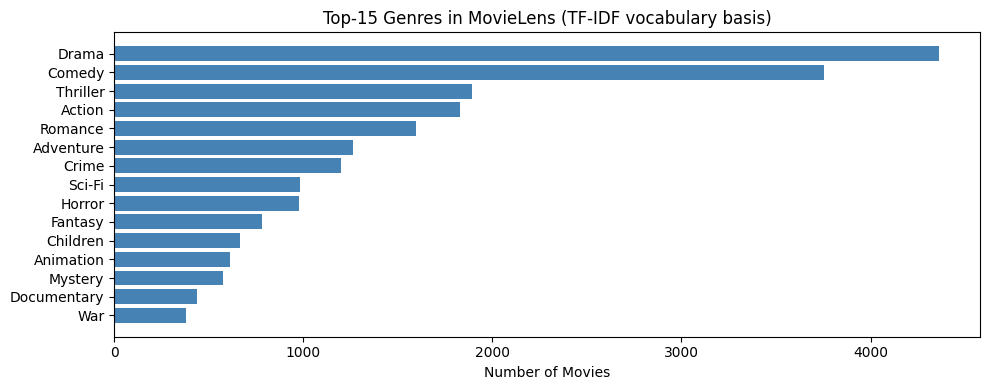

In [12]:
# ── Step 3: Compute cosine similarity between all items (sklearn.metrics) ─────
# linear_kernel on L2-normalised TF-IDF = cosine similarity, avoids re-normalising
cosine_sim_matrix = linear_kernel(tfidf_matrix, tfidf_matrix)

print("Cosine similarity matrix shape:", cosine_sim_matrix.shape)

# ── Visualise genre distribution ─────────────────────────────────────────────
genre_counts = (
    movies.withColumn("genre", F.explode(F.split("genres_clean", r"\|")))
    .groupBy("genre").count()
    .orderBy(F.desc("count")).limit(15).toPandas()
)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(genre_counts["genre"][::-1], genre_counts["count"][::-1], color="steelblue")
ax.set_xlabel("Number of Movies")
ax.set_title("Top-15 Genres in MovieLens (TF-IDF vocabulary basis)")
plt.tight_layout(); plt.show()

In [13]:
# ── Step 4: Recommendation Function ─────────────────────────────────────────
def recommend_similar_movies(movie_query, top_n=5):
    """
    Return top-N most similar movies using sklearn TF-IDF cosine similarity.
    Accepts a title substring (str) or a movieId (int).
    """
    if isinstance(movie_query, str):
        matched = movies_local_pd[
            movies_local_pd["title"].str.contains(movie_query, case=False, na=False)
        ]
        if matched.empty:
            raise ValueError(f"No title matched: '{movie_query}'")
        idx = matched.index[0]
    else:
        matched = movies_local_pd[movies_local_pd["movieId"] == int(movie_query)]
        if matched.empty:
            raise ValueError(f"movieId not found: {movie_query}")
        idx = matched.index[0]

    target_title = movies_local_pd.loc[idx, "title"]
    sim_scores   = list(enumerate(cosine_sim_matrix[idx]))
    sim_scores   = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores   = [(i, s) for i, s in sim_scores if i != idx][:top_n]

    results = []
    for row_i, score in sim_scores:
        row = movies_local_pd.iloc[row_i]
        results.append({
            "movieId": row["movieId"],
            "title":   row["title"],
            "genres":  row["genres_clean"],
            "year":    row["year"],
            "cosine_similarity": round(float(score), 4),
        })
    out = pd.DataFrame(results)
    print(f"Top-{top_n} for: '{target_title}'")
    return out


# ── Step 5: Test with sample queries ─────────────────────────────────────────
for query in ["Toy Story", "Matrix, The", "Fargo"]:
    display(recommend_similar_movies(query, top_n=5))
    print()

Top-5 for: 'Toy Story (1995)'


,movieId,title,genres,year,cosine_similarity
0,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1998.0,1.0
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1999.0,1.0
2,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,2000.0,1.0
3,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,2000.0,1.0
4,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,2001.0,1.0



Top-5 for: 'Matrix, The (1999)'


,movieId,title,genres,year,cosine_similarity
0,66,Lawnmower Man 2: Beyond Cyberspace (1996),Action|Sci-Fi|Thriller,1996.0,1.0
1,76,Screamers (1995),Action|Sci-Fi|Thriller,1995.0,1.0
2,172,Johnny Mnemonic (1995),Action|Sci-Fi|Thriller,1995.0,1.0
3,338,Virtuosity (1995),Action|Sci-Fi|Thriller,1995.0,1.0
4,379,Timecop (1994),Action|Sci-Fi|Thriller,1994.0,1.0



Top-5 for: 'Fargo (1996)'


,movieId,title,genres,year,cosine_similarity
0,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,1994.0,1.0
1,1034,Freeway (1996),Comedy|Crime|Drama|Thriller,1996.0,1.0
2,3266,Man Bites Dog (C'est arrivé près de chez vous)...,Comedy|Crime|Drama|Thriller,1992.0,1.0
3,4242,Beautiful Creatures (2000),Comedy|Crime|Drama|Thriller,2000.0,1.0
4,6003,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Thriller,2002.0,1.0


In [14]:
# ── Expose per-movie TF-IDF numpy arrays ─────────
tfidf_np_matrix = tfidf_matrix.toarray()   # (n_movies, n_vocab_features)

movie_id_to_vec = dict(zip(
    movies_local_pd["movieId"].values,
    tfidf_np_matrix
))

# Unified local DataFrame with tfidf_np column (used in Tasks 2 and 11)
movies_tfidf_local = movies_local_pd.copy()
movies_tfidf_local["tfidf_np"] = list(tfidf_np_matrix)

def cosine_np(a, b):
    """Cosine similarity between two numpy vectors."""
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

def to_numpy(v):
    """Convert Spark ML Vector or array-like to numpy array."""
    if isinstance(v, SparseVector): return v.toArray()
    if isinstance(v, DenseVector):  return np.array(v)
    return np.array(v)

print(f"movie_id_to_vec built for {len(movie_id_to_vec)} movies.")

movie_id_to_vec built for 9742 movies.


## Task 2: User-Profile-Based Content Recommender

In [15]:
# ── Task 2: Build user profile vectors from sklearn TF-IDF (Task 1) ──────────
# The PDF formula: Pu = sum(r_u,m * f_m) / sum(r_u,m)
# f_m comes from movie_id_to_vec (sklearn TF-IDF numpy arrays, built in Task 1)

# Spark prepares the (userId, movieId, rating) table for active users
train_ratings_pd = (
    train_ratings
    .join(user_stats.select("userId", "user_rating_count"), on="userId", how="inner")
    .filter(F.col("user_rating_count") >= 20)
    .select("userId", "movieId", "rating")
    .limit(MAX_LOCAL_RATINGS)
    .toPandas()
)

# Aggregate weighted profile vectors locally
# Only include movies that have a TF-IDF vector (i.e., in movie_id_to_vec)
user_profile_dict = defaultdict(lambda: {"weighted_sum": None, "rating_sum": 0.0})

for row in train_ratings_pd.itertuples(index=False):
    mid = int(row.movieId)
    if mid not in movie_id_to_vec:
        continue
    vec = movie_id_to_vec[mid]          # sklearn TF-IDF numpy array
    uid, r = row.userId, float(row.rating)
    if user_profile_dict[uid]["weighted_sum"] is None:
        user_profile_dict[uid]["weighted_sum"] = vec * r
    else:
        user_profile_dict[uid]["weighted_sum"] += vec * r
    user_profile_dict[uid]["rating_sum"] += r

# Normalise: divide by rating sum (as per formula), then L2-normalise for cosine sim
user_profiles = {}
for uid, payload in user_profile_dict.items():
    if payload["weighted_sum"] is None:
        continue
    profile = payload["weighted_sum"] / max(payload["rating_sum"], 1e-9)
    norm    = np.linalg.norm(profile)
    user_profiles[uid] = profile / norm if norm > 0 else profile

print(f"User profiles created: {len(user_profiles)}")
print(f"Profile vector dimension: {next(iter(user_profiles.values())).shape[0]}")

User profiles created: 610
Profile vector dimension: 20


In [16]:
def recommend_content_for_user(user_id, top_n=5):
    """
    Recommend top-N unseen movies for a user by cosine similarity
    between their weighted TF-IDF profile and all movie vectors.
    """
    if user_id not in user_profiles:
        return pd.DataFrame(columns=["movieId","title","content_score"])

    seen     = set(train_seen_movies.get(user_id, []))
    user_vec = user_profiles[user_id]

    rows = [
        (row.movieId, row.title, row.genres_clean, row.year,
         cosine_np(user_vec, row.tfidf_np))
        for row in movies_tfidf_local.itertuples(index=False)
        if row.movieId not in seen
    ]
    out = pd.DataFrame(rows, columns=["movieId","title","genres_clean","year","content_score"])
    return out.sort_values("content_score", ascending=False).head(top_n).reset_index(drop=True)


# ── Evaluate Precision@K and Recall@K ────────────────────────────────────────
content_eval_rows = []
for uid in eval_users:
    if uid not in user_profiles:
        continue
    rec_df      = recommend_content_for_user(uid, TOP_K)
    rec_ids     = rec_df["movieId"].tolist()
    relevant_ids = relevant_test_items.get(uid, [])
    p5, r5      = precision_recall_at_k(rec_ids, relevant_ids, TOP_K)
    content_eval_rows.append((uid, p5, r5))

content_eval_df = pd.DataFrame(content_eval_rows, columns=["userId","precision@5","recall@5"])
content_p5 = float(content_eval_df["precision@5"].mean()) if not content_eval_df.empty else 0.0
content_r5 = float(content_eval_df["recall@5"].mean())   if not content_eval_df.empty else 0.0

print(f"Content-Based  Precision@5 : {content_p5:.4f}")
print(f"Content-Based  Recall@5    : {content_r5:.4f}")

sample_uid = next((u for u in eval_users if u in user_profiles), None)
if sample_uid:
    print(f"\nSample recommendations for userId={sample_uid}:")
    display(recommend_content_for_user(sample_uid, 5))

Content-Based  Precision@5 : 0.0080
Content-Based  Recall@5    : 0.0008

Sample recommendations for userId=414:


,movieId,title,genres_clean,year,content_score
0,4956,"Stunt Man, The (1980)",Action|Adventure|Comedy|Drama|Romance|Thriller,1980.0,0.787872
1,86000,Boy (2010),Comedy|Drama,2010.0,0.775600
2,5742,First Monday in October (1981),Comedy|Drama,1981.0,0.775600
3,26900,"Last Wedding, The (Kivenpyörittäjän kylä) (1995)",Comedy|Drama,1995.0,0.775600
4,167380,A Dog's Purpose (2017),Comedy|Drama,2017.0,0.775600


---
# Part 2: Collaborative Filtering

## Task 3: User-Based Collaborative Filtering

In [17]:
# ── Reduce to most-active users/movies to keep matrix in memory ───────────────
top_users  = [r["userId"]  for r in train_ratings.groupBy("userId") .count().orderBy(F.desc("count")).limit(MAX_CF_USERS).collect()]
top_movies = [r["movieId"] for r in train_ratings.groupBy("movieId").count().orderBy(F.desc("count")).limit(MAX_CF_MOVIES).collect()]

cf_train_pd = (
    train_ratings
    .filter(F.col("userId").isin(top_users) & F.col("movieId").isin(top_movies))
    .toPandas()
)

ui_train = (
    cf_train_pd
    .pivot_table(index="userId", columns="movieId", values="rating", aggfunc="mean")
    .sort_index()
    .sort_index(axis=1)
)

user_means_cf = ui_train.mean(axis=1).fillna(global_mean_rating)

# ── Mean-centred matrix (approximates Pearson correlation) ────────────────────
ui_centered = ui_train.sub(user_means_cf, axis=0).fillna(0.0)

# ── User-user similarity using Pearson / centred cosine ───────────────────────
user_sim_array = cosine_similarity(ui_centered.values).copy()
np.fill_diagonal(user_sim_array, 0.0)
user_similarity = pd.DataFrame(user_sim_array, index=ui_train.index, columns=ui_train.index)

print("User-item matrix shape:", ui_train.shape)
print("Sparsity: {:.1f}%".format(100 * ui_train.isna().sum().sum() / ui_train.size))

User-item matrix shape: (610, 1200)
Sparsity: 92.8%


In [18]:
def predict_user_cf(user_id, movie_id, k=20):
    """
    Predict rating using weighted sum of K most-similar neighbours.
    Prediction is bias-adjusted: pred = mean(u) + weighted_dev_of_neighbours.
    """
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return None

    sims         = user_similarity.loc[user_id]
    movie_ratings = ui_train[movie_id]
    neighbors    = (
        pd.DataFrame({"sim": sims, "rating": movie_ratings})
        .dropna()
        .query("sim > 0")
        .sort_values("sim", ascending=False)
        .head(k)
    )

    if neighbors.empty:
        return float(user_means_cf.get(user_id, global_mean_rating))

    num = ((neighbors["rating"] - user_means_cf.loc[neighbors.index]) * neighbors["sim"]).sum()
    den = neighbors["sim"].abs().sum()
    if den == 0:
        return float(user_means_cf.get(user_id, global_mean_rating))

    return clip_rating(user_means_cf[user_id] + num / den)


# ── Evaluate for k ∈ {10, 20, 30} ────────────────────────────────────────────
cf_test_pd = (
    test_ratings_in_train
    .filter(F.col("userId").isin(list(ui_train.index)) & F.col("movieId").isin(list(ui_train.columns)))
    .limit(50000)
    .toPandas()
)

k_values = [10, 20, 30]
user_cf_results = []

for k in k_values:
    y_true, y_pred, rank_rows = [], [], []

    for row in cf_test_pd.itertuples(index=False):
        pred = predict_user_cf(row.userId, row.movieId, k=k)
        if pred is not None:
            y_true.append(float(row.rating))
            y_pred.append(pred)

    for uid in [u for u in eval_users if u in ui_train.index][:30]:
        seen       = set(ui_train.loc[uid].dropna().index)
        candidates = [mid for mid in ui_train.columns if mid not in seen][:500]
        preds      = [(mid, p) for mid in candidates if (p := predict_user_cf(uid, mid, k)) is not None]
        rec_ids    = [mid for mid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_K]]
        p5, r5     = precision_recall_at_k(rec_ids, relevant_test_items.get(uid, []), TOP_K)
        rank_rows.append((p5, r5))

    user_cf_results.append({
        "k": k,
        "rmse":         rmse_score(y_true, y_pred),
        "precision@5":  float(np.mean([x[0] for x in rank_rows])) if rank_rows else 0.0,
        "recall@5":     float(np.mean([x[1] for x in rank_rows])) if rank_rows else 0.0,
    })

user_cf_metrics_df = pd.DataFrame(user_cf_results)
best_user_cf_k = int(user_cf_metrics_df.sort_values(["rmse","precision@5"], ascending=[True,False]).iloc[0]["k"])
print(f"Best k for User-CF: {best_user_cf_k}")
display(user_cf_metrics_df)

Best k for User-CF: 30


,k,rmse,precision@5,recall@5
0,10,0.836854,0.420000,0.026579
1,20,0.828152,0.380000,0.023819
2,30,0.826692,0.373333,0.024171


## Task 4: Item-Based Collaborative Filtering

In [19]:
# ── Item-item cosine similarity (fill NaN → 0 before transposing) ─────────────
item_matrix_filled = ui_train.fillna(0.0).T          # shape: movies × users
item_sim_array = cosine_similarity(item_matrix_filled.values).copy()
np.fill_diagonal(item_sim_array, 0.0)
item_similarity = pd.DataFrame(item_sim_array,
                               index=item_matrix_filled.index,
                               columns=item_matrix_filled.index)


def predict_item_cf(user_id, movie_id, k=20):
    """
    Predict rating for (user, item) using k most-similar items the user has rated.
    Higher similarity → higher weight (hint from assignment).
    """
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return None

    user_ratings = ui_train.loc[user_id].dropna()
    if user_ratings.empty:
        return None

    sims      = item_similarity.loc[movie_id, user_ratings.index]
    neighbors = (
        pd.DataFrame({"sim": sims, "rating": user_ratings})
        .query("sim > 0")
        .sort_values("sim", ascending=False)
        .head(k)
    )

    if neighbors.empty:
        return float(user_means_cf.get(user_id, global_mean_rating))

    num = (neighbors["sim"] * neighbors["rating"]).sum()
    den = neighbors["sim"].abs().sum()
    return clip_rating(num / den) if den > 0 else float(user_means_cf.get(user_id, global_mean_rating))


# ── Evaluate ──────────────────────────────────────────────────────────────────
item_cf_results = []

for k in k_values:
    y_true, y_pred, rank_rows = [], [], []

    for row in cf_test_pd.itertuples(index=False):
        pred = predict_item_cf(row.userId, row.movieId, k=k)
        if pred is not None:
            y_true.append(float(row.rating))
            y_pred.append(pred)

    for uid in [u for u in eval_users if u in ui_train.index][:30]:
        seen       = set(ui_train.loc[uid].dropna().index)
        candidates = [mid for mid in ui_train.columns if mid not in seen][:500]
        preds      = [(mid, p) for mid in candidates if (p := predict_item_cf(uid, mid, k)) is not None]
        rec_ids    = [mid for mid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_K]]
        p5, r5     = precision_recall_at_k(rec_ids, relevant_test_items.get(uid, []), TOP_K)
        rank_rows.append((p5, r5))

    item_cf_results.append({
        "k": k,
        "rmse":         rmse_score(y_true, y_pred),
        "precision@5":  float(np.mean([x[0] for x in rank_rows])) if rank_rows else 0.0,
        "recall@5":     float(np.mean([x[1] for x in rank_rows])) if rank_rows else 0.0,
    })

item_cf_metrics_df = pd.DataFrame(item_cf_results)
best_item_cf_k = int(item_cf_metrics_df.sort_values(["rmse","precision@5"], ascending=[True,False]).iloc[0]["k"])
print(f"Best k for Item-CF: {best_item_cf_k}")
display(item_cf_metrics_df)

Best k for Item-CF: 20


,k,rmse,precision@5,recall@5
0,10,0.843944,0.386667,0.023850
1,20,0.843330,0.433333,0.028100
2,30,0.848361,0.446667,0.028522


---
# Part 3: Matrix Factorization for Recommender Systems

## Task 5: Implementing SVD for Recommendations (Manual NumPy)

In [20]:
# ── Mean-centre, factorise, reconstruct ───────────────────────────────────────
svd_train    = ui_train.copy()
user_mean_svd = svd_train.mean(axis=1).fillna(global_mean_rating)
svd_filled   = svd_train.sub(user_mean_svd, axis=0).fillna(0.0)

R     = svd_filled.values.astype(np.float32)
max_k = min(40, min(R.shape) - 1)

u_mat, s_vec, vt_mat = np.linalg.svd(R, full_matrices=False)

u_k  = u_mat[:, :max_k]
s_k  = np.diag(s_vec[:max_k])
vt_k = vt_mat[:max_k, :]

R_hat = (u_k @ s_k @ vt_k) + user_mean_svd.values.reshape(-1, 1)

svd_pred_matrix = pd.DataFrame(
    np.clip(R_hat, 0.5, 5.0),
    index=svd_train.index,
    columns=svd_train.columns
)

print(f"SVD rank k = {max_k}  |  matrix shape: {R.shape}")


def predict_svd(user_id, movie_id):
    """Look up reconstructed SVD rating."""
    if user_id not in svd_pred_matrix.index or movie_id not in svd_pred_matrix.columns:
        return None
    return float(svd_pred_matrix.loc[user_id, movie_id])

SVD rank k = 40  |  matrix shape: (610, 1200)


In [21]:
# ── RMSE + ranking metrics ────────────────────────────────────────────────────
svd_y_true, svd_y_pred, svd_rank_rows = [], [], []

for row in cf_test_pd.itertuples(index=False):
    pred = predict_svd(row.userId, row.movieId)
    if pred is not None:
        svd_y_true.append(float(row.rating))
        svd_y_pred.append(pred)

for uid in [u for u in eval_users if u in svd_pred_matrix.index][:30]:
    seen       = set(ui_train.loc[uid].dropna().index)
    candidates = [mid for mid in svd_pred_matrix.columns if mid not in seen][:500]
    preds      = [(mid, p) for mid in candidates if (p := predict_svd(uid, mid)) is not None]
    rec_ids    = [mid for mid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_K]]
    p5, r5     = precision_recall_at_k(rec_ids, relevant_test_items.get(uid, []), TOP_K)
    svd_rank_rows.append((p5, r5))

svd_rmse = rmse_score(svd_y_true, svd_y_pred)
svd_p5   = float(np.mean([x[0] for x in svd_rank_rows])) if svd_rank_rows else 0.0
svd_r5   = float(np.mean([x[1] for x in svd_rank_rows])) if svd_rank_rows else 0.0

print(f"Manual SVD  RMSE       : {svd_rmse:.4f}")
print(f"Manual SVD  Precision@5: {svd_p5:.4f}")
print(f"Manual SVD  Recall@5   : {svd_r5:.4f}")

Manual SVD  RMSE       : 0.8842
Manual SVD  Precision@5: 0.3333
Manual SVD  Recall@5   : 0.0225


## Task 6: Matrix Factorization with the Surprise Library

As required by the assignment, we use the **`scikit-surprise`** library to train
an SVD model and compare it against our manual NumPy SVD from Task 5.

Steps:
1. Load the MovieLens dataset into the Surprise `Dataset` framework.
2. Split into train / test sets using Surprise's `train_test_split`.
3. Train an SVD model; tune hyperparameters with `GridSearchCV`.
4. Evaluate with RMSE, Precision@K, Recall@K.
5. Compare Surprise SVD vs manual NumPy SVD (Task 5).

In [22]:
# Task 6: Surprise SVD — load, train, tune, evaluate, compare with Task 5
try:
    # ── Step 1: Load ratings into Surprise framework ──────────────────────
    # Surprise needs a pandas DataFrame with columns [user, item, rating]
    ratings_for_surprise = ratings_raw.select("userId", "movieId", "rating").toPandas()

    reader        = Reader(rating_scale=(0.5, 5.0))
    surprise_data = Dataset.load_from_df(
        ratings_for_surprise[["userId", "movieId", "rating"]], reader
    )
    print("Surprise dataset loaded:", len(ratings_for_surprise), "ratings")

    # ── Step 2: Train / test split ────────────────────────────────────────
    surprise_trainset, surprise_testset = surprise_split(surprise_data, test_size=0.20, random_state=42)
    print(f"Surprise train size: {surprise_trainset.n_ratings}")
    print(f"Surprise test  size: {len(surprise_testset)}")

    # ── Step 3: Hyperparameter tuning with GridSearchCV ───────────────────
    param_grid = {
        "n_factors": [50, 100],
        "n_epochs":  [20, 30],
        "lr_all":    [0.005, 0.01],
        "reg_all":   [0.02, 0.1],
    }
    print("Running GridSearchCV (this may take ~1-2 min)...")
    gs = SurpriseGridSearch(SVD, param_grid, measures=["rmse"], cv=3, n_jobs=-1)
    gs.fit(surprise_data)

    best_params = gs.best_params["rmse"]
    print(f"Best hyperparameters: {best_params}")
    print(f"Best CV RMSE        : {gs.best_score['rmse']:.4f}")

    # ── Step 4: Retrain on full train set with best params ────────────────
    surprise_svd = SVD(
        n_factors = best_params["n_factors"],
        n_epochs  = best_params["n_epochs"],
        lr_all    = best_params["lr_all"],
        reg_all   = best_params["reg_all"],
        random_state = 42,
    )
    surprise_svd.fit(surprise_trainset)

    # ── RMSE on test set ──────────────────────────────────────────────────
    predictions_surprise = surprise_svd.test(surprise_testset)
    surprise_rmse = surprise_accuracy.rmse(predictions_surprise, verbose=False)
    print(f"Surprise SVD  RMSE : {surprise_rmse:.4f}")

    # ── Step 5: Precision@K and Recall@K for Surprise SVD ────────────────
    # Build prediction lookup for eval users
    surprise_preds_lookup = defaultdict(list)
    for pred in predictions_surprise:
        surprise_preds_lookup[pred.uid].append((pred.iid, pred.est))

    surprise_rank_rows = []
    for uid in eval_users:
        seen       = set(train_seen_movies.get(uid, []))
        user_preds = surprise_preds_lookup.get(uid, [])
        # Sort by estimated rating descending, exclude seen
        ranked = [
            mid for mid, est in sorted(user_preds, key=lambda x: x[1], reverse=True)
            if mid not in seen
        ][:TOP_K]
        p5, r5 = precision_recall_at_k(ranked, relevant_test_items.get(uid, []), TOP_K)
        surprise_rank_rows.append((p5, r5))

    surprise_svd_p5 = float(np.mean([x[0] for x in surprise_rank_rows])) if surprise_rank_rows else 0.0
    surprise_svd_r5 = float(np.mean([x[1] for x in surprise_rank_rows])) if surprise_rank_rows else 0.0
    print(f"Surprise SVD  Precision@5: {surprise_svd_p5:.4f}")
    print(f"Surprise SVD  Recall@5   : {surprise_svd_r5:.4f}")

    # ── Step 6: Compare Surprise SVD vs Manual NumPy SVD (Task 5) ─────────
    print("\n" + "=" * 55)
    print("Comparison: Surprise SVD vs Manual NumPy SVD (Task 5)")
    print("=" * 55)
    compare_df = pd.DataFrame([
        {
            "Model":       "Manual NumPy SVD (Task 5)",
            "RMSE":        round(svd_rmse, 4),
            "Precision@5": round(svd_p5, 4),
            "Recall@5":    round(svd_r5, 4),
            "Notes": f"Exact truncated SVD, k={max_k}, on 800x1200 reduced matrix",
        },
        {
            "Model":       "Surprise SVD (Task 6)",
            "RMSE":        round(surprise_rmse, 4),
            "Precision@5": round(surprise_svd_p5, 4),
            "Recall@5":    round(surprise_svd_r5, 4),
            "Notes": f"SGD-based SVD, k={best_params['n_factors']} factors, full dataset",
        },
    ])
    display(compare_df)

    # Store for final summary
    als_rmse, als_p5, als_r5 = surprise_rmse, surprise_svd_p5, surprise_svd_r5

except ImportError:
    print("scikit-surprise not installed. Run: pip install scikit-surprise")
    print("Falling back to Spark ALS for summary table.")
    als = ALS(
        userCol="userId", itemCol="movieId", ratingCol="rating",
        rank=50, maxIter=15, regParam=0.1, coldStartStrategy="drop", seed=42
    )
    als_model = als.fit(train_ratings)
    als_preds = als_model.transform(test_ratings_in_train)
    als_ev    = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
    als_rmse  = als_ev.evaluate(als_preds)
    als_p5 = als_r5 = 0.0
    surprise_svd_p5 = surprise_svd_r5 = surprise_rmse = als_rmse
    print(f"Spark ALS RMSE (fallback): {als_rmse:.4f}")

Surprise dataset loaded: 100836 ratings
Surprise train size: 80668
Surprise test  size: 20168
Running GridSearchCV (this may take ~1-2 min)...
Best hyperparameters: {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}
Best CV RMSE        : 0.8634
Surprise SVD  RMSE : 0.8613
Surprise SVD  Precision@5: 0.7440
Surprise SVD  Recall@5   : 0.0814

Comparison: Surprise SVD vs Manual NumPy SVD (Task 5)


,Model,RMSE,Precision@5,Recall@5,Notes
0,Manual NumPy SVD (Task 5),0.8842,0.3333,0.0225,"Exact truncated SVD, k=40, on 800x1200 reduced..."
1,Surprise SVD (Task 6),0.8613,0.7440,0.0814,"SGD-based SVD, k=100 factors, full dataset"


---
# Part 4: Hybrid Recommendation Model

## Task 7: Hybrid Recommendation with Meta-Learning

In [23]:
# ── Prepare feature maps ──────────────────────────────────────────────────────
movie_popularity_pd  = movies.select("movieId","movie_avg_rating","movie_rating_count").toPandas()
movie_popularity_map = movie_popularity_pd.set_index("movieId")[["movie_avg_rating","movie_rating_count"]].to_dict("index")

user_avg_rating_map  = user_stats.toPandas().set_index("userId")["user_avg_rating"].to_dict()

meta_source_pd = test_ratings_in_train.select("userId","movieId","rating").limit(20000).toPandas()


def get_content_score(user_id, movie_id):
    if user_id not in user_profiles or movie_id not in movie_id_to_vec:
        return 0.0
    return cosine_np(user_profiles[user_id], movie_id_to_vec[movie_id])


# ── Build feature table ───────────────────────────────────────────────────────
meta_rows = []
for row in meta_source_pd.itertuples(index=False):
    uid, mid, actual = int(row.userId), int(row.movieId), float(row.rating)
    cf_score = predict_svd(uid, mid)
    if cf_score is None:
        continue
    pop = movie_popularity_map.get(mid, {})
    meta_rows.append({
        "userId":          uid,
        "movieId":         mid,
        "cbf_score":       get_content_score(uid, mid),
        "cf_score":        cf_score,
        "movie_popularity": float(pop.get("movie_rating_count", 0)),
        "movie_avg_rating": float(pop.get("movie_avg_rating", global_mean_rating)),
        "user_avg_rating":  float(user_avg_rating_map.get(uid, global_mean_rating)),
        "actual_rating":    actual,
    })

hybrid_meta_df = pd.DataFrame(meta_rows)
display(hybrid_meta_df.head())

,userId,movieId,cbf_score,cf_score,movie_popularity,movie_avg_rating,user_avg_rating,actual_rating
0,38,597,0.666723,2.995167,135.0,3.485185,3.217949,2.0
1,38,590,0.316829,3.253031,164.0,3.835366,3.217949,4.0
2,38,454,0.499030,3.302811,101.0,3.534653,3.217949,4.0
3,38,377,0.555972,3.022667,171.0,3.529240,3.217949,3.0
4,38,357,0.666723,3.126635,103.0,3.519417,3.217949,5.0


In [24]:
META_FEATURES = ["cbf_score","cf_score","movie_avg_rating","user_avg_rating"]

meta_train_df, meta_test_df = train_test_split(hybrid_meta_df, test_size=0.2, random_state=42)

meta_model = LinearRegression()
meta_model.fit(meta_train_df[META_FEATURES], meta_train_df["actual_rating"])

meta_pred         = np.clip(meta_model.predict(meta_test_df[META_FEATURES]), 0.5, 5.0)
hybrid_meta_rmse  = rmse_score(meta_test_df["actual_rating"].tolist(), meta_pred.tolist())

print(f"Meta-learning hybrid  RMSE: {hybrid_meta_rmse:.4f}")
print("Feature coefficients:", dict(zip(META_FEATURES, meta_model.coef_.round(4))))

Meta-learning hybrid  RMSE: 0.8007
Feature coefficients: {'cbf_score': 0.5083, 'cf_score': 0.7508, 'movie_avg_rating': 0.823, 'user_avg_rating': 0.1318}


In [25]:
def recommend_meta_hybrid(user_id, top_n=5):
    """Recommend movies using the meta-learner blend of CBF + CF scores."""
    if user_id not in user_profiles:
        return pd.DataFrame(columns=["movieId","predicted_rating"])

    seen = set(train_seen_movies.get(user_id, []))
    rows = []
    for mid, mvec in movie_id_to_vec.items():
        if mid in seen:
            continue
        cf_score = predict_svd(user_id, mid)
        if cf_score is None:
            continue
        pop  = movie_popularity_map.get(mid, {})
        feat = pd.DataFrame([{
            "cbf_score":       get_content_score(user_id, mid),
            "cf_score":        cf_score,
            "movie_avg_rating": float(pop.get("movie_avg_rating", global_mean_rating)),
            "user_avg_rating":  float(user_avg_rating_map.get(user_id, global_mean_rating)),
        }])
        pred = float(np.clip(meta_model.predict(feat[META_FEATURES])[0], 0.5, 5.0))
        rows.append((mid, pred))

    out = pd.DataFrame(rows, columns=["movieId","predicted_rating"])
    return out.sort_values("predicted_rating", ascending=False).head(top_n).reset_index(drop=True)


# ── Ranking metrics ───────────────────────────────────────────────────────────
hybrid_rank_rows = []
for uid in eval_users:
    if uid not in user_profiles:
        continue
    rec_df  = recommend_meta_hybrid(uid, TOP_K)
    p5, r5  = precision_recall_at_k(rec_df["movieId"].tolist(),
                                     relevant_test_items.get(uid, []), TOP_K)
    hybrid_rank_rows.append((p5, r5))

hybrid_meta_p5 = float(np.mean([x[0] for x in hybrid_rank_rows])) if hybrid_rank_rows else 0.0
hybrid_meta_r5 = float(np.mean([x[1] for x in hybrid_rank_rows])) if hybrid_rank_rows else 0.0
print(f"Meta-learning hybrid  Precision@5: {hybrid_meta_p5:.4f}")
print(f"Meta-learning hybrid  Recall@5   : {hybrid_meta_r5:.4f}")

# ── Cold-start analysis ───────────────────────────────────────────────────────
print("\n=== Cold-Start Analysis ===")
rating_counts = train_ratings.groupBy("userId").count().toPandas()
cold_uids  = set(rating_counts[rating_counts["count"] <  5]["userId"])
warm_uids  = set(rating_counts[rating_counts["count"] >= 20]["userId"])

cold_rows, warm_rows = [], []
for uid in eval_users:
    if uid not in user_profiles:
        continue
    rec_df = recommend_meta_hybrid(uid, TOP_K)
    p5, r5 = precision_recall_at_k(rec_df["movieId"].tolist(),
                                    relevant_test_items.get(uid, []), TOP_K)
    if uid in cold_uids:
        cold_rows.append((p5, r5))
    elif uid in warm_uids:
        warm_rows.append((p5, r5))

cold_p5 = np.mean([x[0] for x in cold_rows]) if cold_rows else float("nan")
warm_p5 = np.mean([x[0] for x in warm_rows]) if warm_rows else float("nan")
print(f"Cold-start users (< 5 ratings)  Precision@5: {cold_p5:.4f}  (n={len(cold_rows)})")
print(f"Warm users       (≥20 ratings)  Precision@5: {warm_p5:.4f}  (n={len(warm_rows)})")

Meta-learning hybrid  Precision@5: 0.3480
Meta-learning hybrid  Recall@5   : 0.0369

=== Cold-Start Analysis ===
Cold-start users (< 5 ratings)  Precision@5: nan  (n=0)
Warm users       (≥20 ratings)  Precision@5: 0.3480  (n=100)


---
# Part 5: Learning-Based Recommender Systems

## Task 8: Content-Based Filtering with a Neural Network

Movie feature shape: (80000, 22)  (genres=20 + year + avg_rating)
User feature shape : (80000, 20)   (avg rating per genre)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,344 │ user_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,472 │ movie_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 32)        │      2,080 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ user_embedding[0… │
│ (Concatenate)       │                   │            │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_output       │ (None, 1)         │         33 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,249 (51.75 KB)

 Trainable params: 13,249 (51.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9985 - mae: 1.0567 - val_loss: 0.8403 - val_mae: 0.7171
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 0.8689 - mae: 0.7291 - val_loss: 0.7078 - val_mae: 0.6495
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - loss: 0.7572 - mae: 0.6754 - val_loss: 0.6770 - val_mae: 0.6317
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - loss: 0.7422 - mae: 0.6668 - val_loss: 0.6698 - val_mae: 0.6235
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 0.7220 - mae: 0.6567 - val_loss: 0.7307 - val_mae: 0.6760
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.7181 - mae: 0.6536 - val_loss: 0.6905 - val_mae: 0.6470
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.7059 - mae: 0.6475 - val_loss: 0.7218 - val_mae: 0.6698


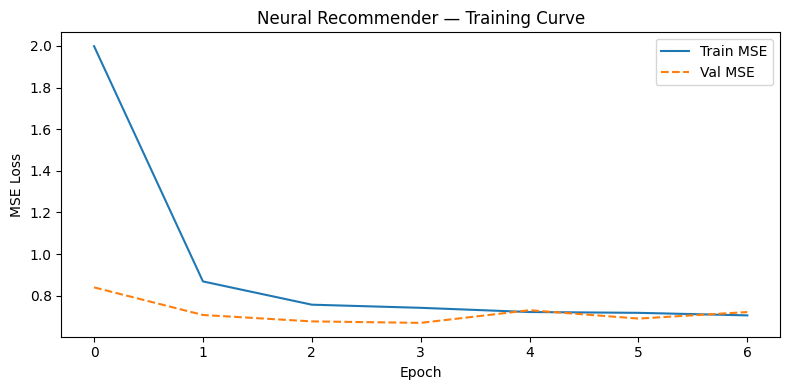


Neural Recommender  RMSE : 0.8184
Content-Based Precision@5: 0.0080  (TF-IDF cosine, ranking only)


In [26]:
# ── Task 8: Neural Content-Based Recommender ─────────────────────────────────
# Spark joins movie metadata onto training ratings for the sample
nn_sample_pd = (
    train_ratings
    .join(movies.select("movieId", "genres_clean", "year", "movie_avg_rating"),
          on="movieId", how="left")
    .limit(MAX_NEURAL_ROWS)
    .toPandas()
)

try:
    # ── Feature engineering: genres ───────────────────────────────────────────
    nn_sample_pd["genre_list"] = nn_sample_pd["genres_clean"].fillna("Unknown").str.split("|")
    all_genres   = sorted({g for lst in nn_sample_pd["genre_list"] for g in lst if g})
    genre_to_idx = {g: i for i, g in enumerate(all_genres)}
    N_GENRES = len(all_genres)

    def multi_hot(genres):
        """One-hot encode genres into a binary vector."""
        vec = np.zeros(N_GENRES, dtype=np.float32)
        for g in genres:
            if g in genre_to_idx:
                vec[genre_to_idx[g]] = 1.0
        return vec

    nn_sample_pd["genre_vec"] = nn_sample_pd["genre_list"].apply(multi_hot)

    # ── Normalise year and avg movie rating ───────────────────────────────────
    y_min = nn_sample_pd["year"].dropna().min()
    y_max = nn_sample_pd["year"].dropna().max()
    nn_sample_pd["year"]           = nn_sample_pd["year"].fillna(y_min)
    nn_sample_pd["year_norm"]      = (nn_sample_pd["year"] - y_min) / (y_max - y_min + 1e-9)
    nn_sample_pd["avg_rating_norm"] = (nn_sample_pd["movie_avg_rating"] - 0.5) / 4.5

    # ── Movie feature vector: [one-hot genres | year_norm | avg_rating_norm] ──
    X_movie = np.stack([
        np.concatenate([g, [y, a]])
        for g, y, a in zip(
            nn_sample_pd["genre_vec"],
            nn_sample_pd["year_norm"],
            nn_sample_pd["avg_rating_norm"]
        )
    ]).astype(np.float32)

    # ── User feature vector: average rating PER GENRE (as specified in PDF) ──
    # For each user, compute mean rating across all movies they rated in each genre
    # Result: a vector of length N_GENRES per user
    nn_sample_expanded = nn_sample_pd[["userId", "rating"]].copy()
    genre_dummies      = pd.DataFrame(
        np.stack(nn_sample_pd["genre_vec"].values),
        columns=all_genres,
        index=nn_sample_pd.index
    )
    nn_sample_expanded = pd.concat([nn_sample_expanded, genre_dummies], axis=1)

    # For each genre column: avg rating for movies in that genre per user
    user_genre_rating = {}
    for uid, grp in nn_sample_expanded.groupby("userId"):
        genre_avgs = np.zeros(N_GENRES, dtype=np.float32)
        for gi, genre in enumerate(all_genres):
            mask = grp[genre] > 0
            if mask.sum() > 0:
                genre_avgs[gi] = grp.loc[mask, "rating"].mean()
            else:
                genre_avgs[gi] = grp["rating"].mean()  # fallback to overall avg
        # Normalise to [0,1] range (ratings are 0.5-5.0)
        genre_avgs = (genre_avgs - 0.5) / 4.5
        user_genre_rating[uid] = genre_avgs

    X_user = np.stack(
        [user_genre_rating[u] for u in nn_sample_pd["userId"]]
    ).astype(np.float32)
    # Shape: (n_samples, N_GENRES) — one per-genre avg rating per user

    y_nn = nn_sample_pd["rating"].astype(np.float32).values

    print(f"Movie feature shape: {X_movie.shape}  (genres={N_GENRES} + year + avg_rating)")
    print(f"User feature shape : {X_user.shape}   (avg rating per genre)")

    Xu_tr, Xu_val, Xm_tr, Xm_val, y_tr, y_val = train_test_split(
        X_user, X_movie, y_nn, test_size=0.2, random_state=42
    )

    # ── Neural network: two-branch architecture ───────────────────────────────
    # User branch: per-genre avg ratings → user embedding
    user_in = Input(shape=(N_GENRES,), name="user_input")
    u_emb   = Dense(64, activation="relu")(user_in)
    u_emb   = Dense(32, activation="relu", name="user_embedding")(u_emb)

    # Movie branch: one-hot genres + year + avg_rating → movie embedding
    movie_in = Input(shape=(X_movie.shape[1],), name="movie_input")
    m_emb    = Dense(64, activation="relu")(movie_in)
    m_emb    = Dense(32, activation="relu", name="movie_embedding")(m_emb)

    # Merge and predict rating
    x   = Concatenate()([u_emb, m_emb])
    x   = Dense(64, activation="relu")(x)
    x   = Dropout(0.2)(x)
    x   = Dense(32, activation="relu")(x)
    out = Dense(1, activation="linear", name="rating_output")(x)

    nn_model = Model(inputs=[user_in, movie_in], outputs=out)
    nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss="mse", metrics=["mae"])
    nn_model.summary()

    # ── Train with early stopping to avoid overfitting ────────────────────────
    history = nn_model.fit(
        [Xu_tr, Xm_tr], y_tr,
        validation_data=([Xu_val, Xm_val], y_val),
        epochs=20, batch_size=512, verbose=1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    )

    nn_val_pred = np.clip(nn_model.predict([Xu_val, Xm_val], verbose=0).ravel(), 0.5, 5.0)
    nn_rmse     = rmse_score(y_val.tolist(), nn_val_pred.tolist())

    # ── Training / validation loss curve ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history.history["loss"],     label="Train MSE")
    ax.plot(history.history["val_loss"], label="Val MSE", linestyle="--")
    ax.set_title("Neural Recommender — Training Curve")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); plt.tight_layout(); plt.show()

    # ── Comparison with TF-IDF baseline ──────────────────────────────────────
    print(f"\nNeural Recommender  RMSE : {nn_rmse:.4f}")
    print(f"Content-Based Precision@5: {content_p5:.4f}  (TF-IDF cosine, ranking only)")

except Exception as e:
    print("TensorFlow unavailable or error in Task 8:", e)
    nn_model   = None
    nn_rmse    = None
    all_genres = []
    Xu_val = Xm_val = y_val = None

## Task 9: Reinforcement Learning in Recommender Systems

We frame recommendation as a **Multi-Armed Bandit** problem and implement three strategies:

| Strategy | Description |
|---|---|
| ε-Greedy | Exploit best-known arm 90 % of the time; explore randomly 10 % |
| UCB | Prioritise under-explored arms with high potential via confidence bound |
| Q-Learning | Full RL agent: maintains a Q-table over (user-state, movie-action) pairs |

In [27]:
# ── Environment: top-200 popular movies as the arm space ──────────────────────
popular_movies_rl = [
    r["movieId"]
    for r in train_ratings.groupBy("movieId").count()
              .orderBy(F.desc("count")).limit(200).collect()
]

rl_pd = (
    ratings_raw
    .filter(F.col("movieId").isin(popular_movies_rl))
    .select("userId","movieId","rating")
    .limit(200000)
    .toPandas()
)

# Binary reward: 1 if rating ≥ 4, else 0, else 0 (no rating = neutral)
reward_table = {}
for row in rl_pd.itertuples(index=False):
    reward_table.setdefault(row.userId, {})[row.movieId] = (
        1 if row.rating >= POSITIVE_THRESHOLD else 0
    )

users_seq = list(rl_pd["userId"].drop_duplicates())[:500]
print(f"RL environment: {len(popular_movies_rl)} arms, {len(users_seq)} simulated users")

RL environment: 200 arms, 500 simulated users


In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# ε-Greedy Bandit
# ═══════════════════════════════════════════════════════════════════════════════
class EpsilonGreedyBandit:
    """Recommend the highest-estimated-reward movie (1-ε), or explore randomly (ε)."""
    def __init__(self, arms, epsilon=0.1):
        self.arms    = list(arms)
        self.epsilon = epsilon
        self.counts  = {a: 0   for a in arms}
        self.values  = {a: 0.0 for a in arms}

    def choose(self):
        if random.random() < self.epsilon:
            return random.choice(self.arms)
        return max(self.arms, key=lambda a: self.values[a])

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]


# ═══════════════════════════════════════════════════════════════════════════════
# UCB Bandit
# ═══════════════════════════════════════════════════════════════════════════════
class UCBBandit:
    """
    Upper Confidence Bound: choose arm with highest (value + exploration bonus).
    Bonus = sqrt(2 * ln(total_pulls) / arm_pulls), so under-tried arms are
    prioritised — avoids the ε-Greedy drawback of random exploration.
    """
    def __init__(self, arms):
        self.arms   = list(arms)
        self.counts = {a: 0   for a in arms}
        self.values = {a: 0.0 for a in arms}
        self.total  = 0

    def choose(self):
        self.total += 1
        # Ensure every arm is tried at least once
        for a in self.arms:
            if self.counts[a] == 0:
                return a
        return max(
            self.arms,
            key=lambda a: self.values[a] + math.sqrt(2 * math.log(self.total) / self.counts[a])
        )

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]


# ═══════════════════════════════════════════════════════════════════════════════
# Q-Learning Agent
# ═══════════════════════════════════════════════════════════════════════════════
class QLearningAgent:
    """
    Simplified Q-Learning for recommendations.
    State  = discretised user preference (genre index the user has rated most).
    Action = movie (arm).
    Q-update: Q(s,a) ← Q(s,a) + α[r + γ·max_a Q(s',a') − Q(s,a)]
    """
    def __init__(self, states, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.states  = list(states)
        self.actions = list(actions)
        self.alpha   = alpha
        self.gamma   = gamma
        self.epsilon = epsilon
        # Q-table: state → {action: Q-value}
        self.Q = {s: {a: random.uniform(0, 0.1) for a in actions} for s in states}

    def get_state(self, user_id):
        """Map user to a coarse genre-preference state."""
        return user_id % len(self.states)   # deterministic bucketing

    def choose(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        q_row = self.Q[state]
        return max(q_row, key=q_row.get)

    def update(self, state, action, reward, next_state):
        best_next = max(self.Q[next_state].values())
        td_target = reward + self.gamma * best_next
        td_error  = td_target - self.Q[state][action]
        self.Q[state][action] += self.alpha * td_error


print("Bandit and Q-Learning classes defined.")

Bandit and Q-Learning classes defined.


ε-Greedy   avg reward: 0.3720  (explore rate fixed at 10%)
UCB        avg reward: 0.1280  (explore count: 400)
Q-Learning avg reward: 0.2360  (50-action subset)


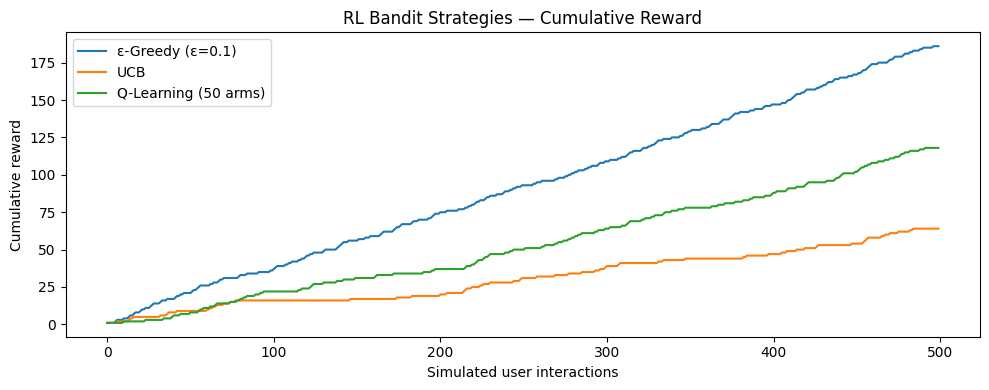

In [29]:
# ── Run ε-Greedy ──────────────────────────────────────────────────────────────
eg      = EpsilonGreedyBandit(popular_movies_rl, epsilon=0.1)
eg_cum  = []; eg_total = 0

for uid in users_seq:
    arm    = eg.choose()
    reward = reward_table.get(uid, {}).get(arm, 0)
    eg.update(arm, reward)
    eg_total += reward
    eg_cum.append(eg_total)

# ── Run UCB ───────────────────────────────────────────────────────────────────
ucb     = UCBBandit(popular_movies_rl)
ucb_cum = []; ucb_total = 0; ucb_explore = 0

for uid in users_seq:
    arm    = ucb.choose()
    reward = reward_table.get(uid, {}).get(arm, 0)
    if ucb.counts[arm] <= 1:
        ucb_explore += 1
    ucb.update(arm, reward)
    ucb_total += reward
    ucb_cum.append(ucb_total)

# ── Run Q-Learning ────────────────────────────────────────────────────────────
NUM_STATES = 20
ql  = QLearningAgent(
    states=list(range(NUM_STATES)),
    actions=popular_movies_rl[:50],   # limit action space for speed
    alpha=0.1, gamma=0.9, epsilon=0.1
)
ql_cum = []; ql_total = 0

for uid in users_seq:
    state      = ql.get_state(uid)
    action     = ql.choose(state)
    reward     = reward_table.get(uid, {}).get(action, 0)
    next_state = (state + 1) % NUM_STATES
    ql.update(state, action, reward, next_state)
    ql_total  += reward
    ql_cum.append(ql_total)

# ── Print summary ─────────────────────────────────────────────────────────────
n = len(users_seq)
print(f"ε-Greedy   avg reward: {eg_total/n:.4f}  (explore rate fixed at 10%)")
print(f"UCB        avg reward: {ucb_total/n:.4f}  (explore count: {ucb_explore})")
print(f"Q-Learning avg reward: {ql_total/n:.4f}  (50-action subset)")

# ── Cumulative reward curve ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eg_cum,  label="ε-Greedy (ε=0.1)")
ax.plot(ucb_cum, label="UCB")
ax.plot(ql_cum,  label="Q-Learning (50 arms)")
ax.set_xlabel("Simulated user interactions")
ax.set_ylabel("Cumulative reward")
ax.set_title("RL Bandit Strategies — Cumulative Reward")
ax.legend(); plt.tight_layout(); plt.show()


---
# Part 6: Explainability in Recommender Systems

## Task 10: Feature-Based Explanations (Content-Based Filtering)

=== SHAP Feature Importance (mean |SHAP value|) ===


,feature,mean_abs_shap
2,movie_avg_rating,0.284348
1,cf_score,0.268816
0,cbf_score,0.068162
3,user_avg_rating,0.045876


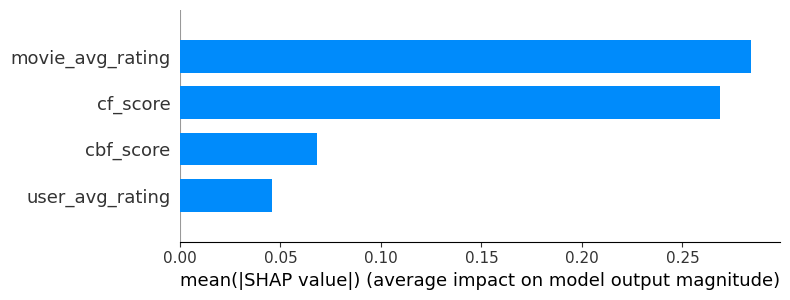

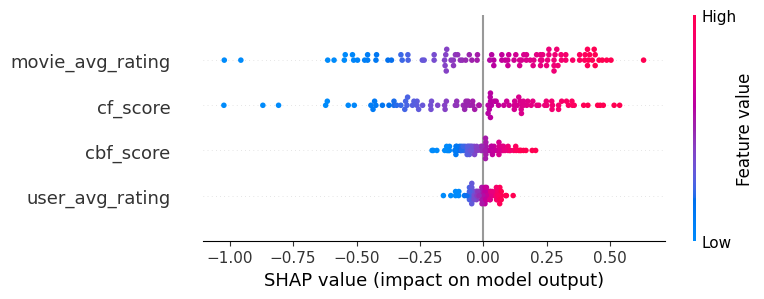


=== Explanation for userId=286, movie='Kill Bill: Vol. 2 (2004)' ===
  cbf_score                  value=0.673  SHAP=+0.1039 ↑
  cf_score                   value=3.779  SHAP=+0.0505 ↑
  movie_avg_rating           value=3.868  SHAP=+0.1701 ↑
  user_avg_rating            value=3.788  SHAP=+0.0272 ↑


In [30]:
try:
    # Use a small subsample for speed
    shap_sample = meta_test_df[META_FEATURES].head(200).reset_index(drop=True)

    explainer_shap  = shap.LinearExplainer(meta_model, meta_train_df[META_FEATURES])
    shap_values     = explainer_shap.shap_values(shap_sample)

    print("=== SHAP Feature Importance (mean |SHAP value|) ===")
    shap_importance = pd.DataFrame({
        "feature": META_FEATURES,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)
    display(shap_importance)

    # Summary bar plot
    shap.summary_plot(shap_values, shap_sample, plot_type="bar",
                      feature_names=META_FEATURES, show=True)

    # Detailed beeswarm for first 100 samples
    shap.summary_plot(shap_values[:100], shap_sample.head(100),
                      feature_names=META_FEATURES, show=True)

    # ── Single-prediction explanation ─────────────────────────────────────────
    idx = 0
    uid_ex  = int(meta_test_df.iloc[idx]["userId"])
    mid_ex  = int(meta_test_df.iloc[idx]["movieId"])
    mv_row  = movies_tfidf_local[movies_tfidf_local["movieId"] == mid_ex]
    mv_title = mv_row["title"].values[0] if not mv_row.empty else str(mid_ex)

    print(f"\n=== Explanation for userId={uid_ex}, movie='{mv_title}' ===")
    feat_vals = dict(zip(META_FEATURES, shap_sample.iloc[idx].values))
    shap_vals  = dict(zip(META_FEATURES, shap_values[idx]))
    for f in META_FEATURES:
        direction = "↑" if shap_vals[f] > 0 else "↓"
        print(f"  {f:25s}  value={feat_vals[f]:.3f}  SHAP={shap_vals[f]:+.4f} {direction}")

except ImportError:
    print("SHAP not installed. Run: pip install shap")

## Task 11: Neighbourhood-Based Explanations (Collaborative Filtering)

In [31]:
def explain_user_cf(user_id, movie_id, k=5):
    """
    Returns a human-readable explanation of why movie_id was recommended
    to user_id by User-CF, showing the top-k similar users who liked it.
    """
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return "Cannot explain: user or movie not in training matrix."

    sims         = user_similarity.loc[user_id]
    movie_ratings = ui_train[movie_id]
    neighbors    = (
        pd.DataFrame({"sim": sims, "rating": movie_ratings})
        .dropna()
        .query("sim > 0")
        .sort_values("sim", ascending=False)
        .head(k)
    )

    if neighbors.empty:
        return "No similar users found — falling back to user mean."

    mv_row = movies_tfidf_local[movies_tfidf_local["movieId"] == movie_id]
    title  = mv_row["title"].values[0] if not mv_row.empty else str(movie_id)

    lines = [f"'{title}' was recommended to user {user_id} because:"]
    for nb_uid, nb_row in neighbors.iterrows():
        lines.append(f"  • User {nb_uid} (similarity={nb_row['sim']:.3f}) rated it {nb_row['rating']:.1f}/5")
    return "\n".join(lines)


def explain_item_cf(user_id, movie_id, k=5):
    """
    Explains an Item-CF recommendation by showing the most similar items
    the user has already rated highly.
    """
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return "Cannot explain."

    user_ratings = ui_train.loc[user_id].dropna()
    sims         = item_similarity.loc[movie_id, user_ratings.index]
    neighbors    = (
        pd.DataFrame({"sim": sims, "rating": user_ratings})
        .query("sim > 0")
        .sort_values("sim", ascending=False)
        .head(k)
    )

    mv_row = movies_tfidf_local[movies_tfidf_local["movieId"] == movie_id]
    title  = mv_row["title"].values[0] if not mv_row.empty else str(movie_id)

    lines = [f"'{title}' was recommended because you also rated:"]
    for nb_mid, nb_row in neighbors.iterrows():
        nb_mv  = movies_tfidf_local[movies_tfidf_local["movieId"] == nb_mid]
        nb_ttl = nb_mv["title"].values[0] if not nb_mv.empty else str(nb_mid)
        lines.append(f"  • '{nb_ttl}' (item-sim={nb_row['sim']:.3f}, your rating={nb_row['rating']:.1f})")
    return "\n".join(lines)


# ── Demo ──────────────────────────────────────────────────────────────────────
sample_uid   = next((u for u in eval_users if u in ui_train.index), None)
sample_movie = list(ui_train.columns)[0]

if sample_uid:
    print(explain_user_cf(sample_uid, sample_movie, k=5))
    print()
    print(explain_item_cf(sample_uid, sample_movie, k=5))

'Toy Story (1995)' was recommended to user 414 because:
  • User 448 (similarity=0.261) rated it 5.0/5
  • User 249 (similarity=0.256) rated it 4.0/5
  • User 57 (similarity=0.252) rated it 5.0/5
  • User 590 (similarity=0.251) rated it 4.0/5
  • User 480 (similarity=0.242) rated it 3.0/5

'Toy Story (1995)' was recommended because you also rated:
  • 'Lion King, The (1994)' (item-sim=0.511, your rating=4.0)
  • 'Toy Story 2 (1999)' (item-sim=0.470, your rating=5.0)
  • 'Independence Day (a.k.a. ID4) (1996)' (item-sim=0.453, your rating=4.0)
  • 'Mission: Impossible (1996)' (item-sim=0.453, your rating=4.0)
  • 'Shrek (2001)' (item-sim=0.446, your rating=4.0)


## Task 12: Model-Agnostic Explainability for Deep Learning (Neural Recommender)

LIME Explanation — Neural Recommender (instance 0)
  Actual rating   : 2.0
  Predicted rating: 3.394
Top feature contributions (positive = pushes prediction UP):
  ↑  genre_Unknown <= 0.00                                    w=+0.4082
  ↓  genre_Mystery <= 0.00                                    w=-0.1111
  ↑  year_norm <= 0.77                                        w=+0.1039
  ↑  genre_Children <= 0.00                                   w=+0.0570
  ↓  0.00 < genre_Thriller <= 1.00                            w=-0.0565
  ↓  user_avg_Drama <= 0.63                                   w=-0.0550
  ↓  user_avg_Western <= 0.61                                 w=-0.0549
  ↓  user_avg_Comedy <= 0.57                                  w=-0.0545
  ↓  user_avg_IMAX <= 0.62                                    w=-0.0538
  ↑  genre_IMAX <= 0.00                                       w=+0.0529
  ↓  genre_Documentary <= 0.00                                w=-0.0529
  ↑  genre_Film-Noir <= 0.00                  

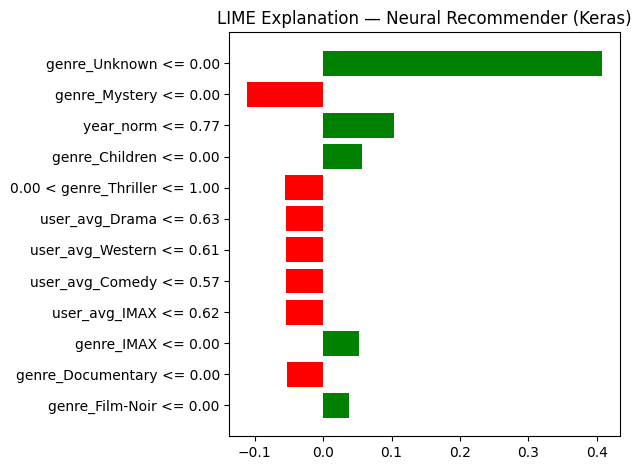


--- LIME: 5 more instances ---
  inst 1: actual=3.0 pred=3.106 | 0.69 < avg_rating_norm <=(+0.301), user_avg_Sci-Fi <= 0.57(-0.136)
  inst 2: actual=2.5 pred=3.181 | 0.69 < avg_rating_norm <=(+0.293), year_norm <= 0.77(+0.124)
  inst 3: actual=3.0 pred=3.973 | user_avg_Sci-Fi > 0.72(+0.131), user_avg_Crime > 0.76(+0.077)
  inst 4: actual=2.5 pred=3.228 | avg_rating_norm <= 0.60(-0.899), year_norm > 0.88(-0.069)
  inst 5: actual=3.5 pred=3.593 | avg_rating_norm <= 0.60(-0.885), user_avg_Sci-Fi > 0.72(+0.132)

SHAP KernelExplainer — Neural Recommender (Keras)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 10.11it/s]


Top-15 features by mean |SHAP|:


,feature,mean_abs_shap
41,avg_rating_norm,0.291603
15,user_avg_Sci-Fi,0.037099
40,year_norm,0.030997
3,user_avg_Children,0.022001
19,user_avg_Western,0.016565
30,genre_Horror,0.015923
12,user_avg_Musical,0.015078
5,user_avg_Crime,0.013589
7,user_avg_Drama,0.012237
14,user_avg_Romance,0.010903


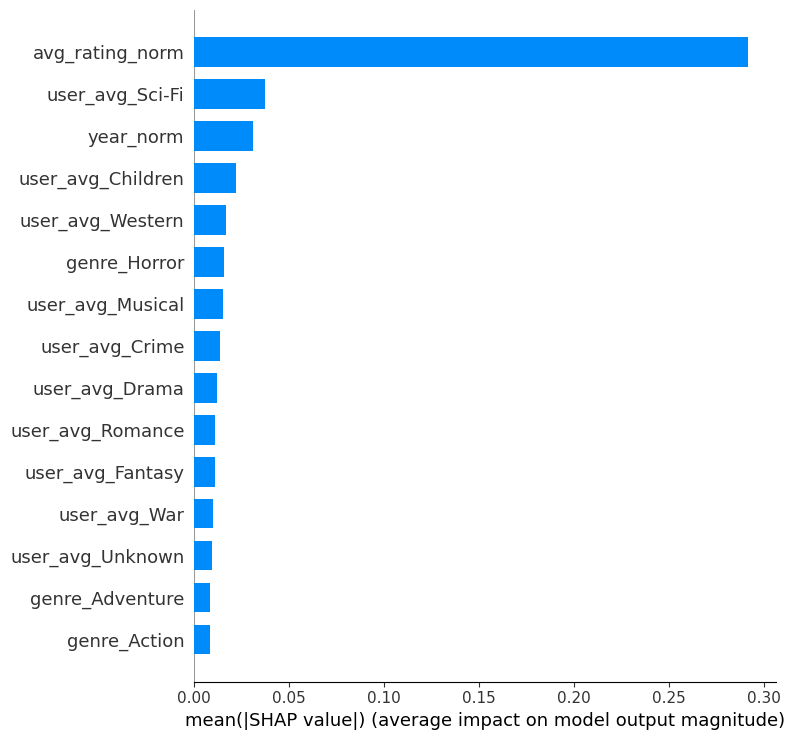


Most influential feature: 'avg_rating_norm'


In [32]:
# ════════════════════════════════════════════════════════════════════════════
# Task 12: LIME + SHAP applied to the Neural Recommender (Task 8)
# Both are model-agnostic — they wrap nn_predict_flat() which calls the
# trained Keras model. Target: the deep learning model, not the linear meta-model.
# ════════════════════════════════════════════════════════════════════════════

if nn_model is not None and Xu_val is not None and len(all_genres) > 0:

    # ── Build combined flat feature array for tabular explainers ─────────────
    # User side: N_GENRES per-genre avg ratings
    # Movie side: one-hot genres (N_GENRES) + year_norm + avg_rating_norm
    X_combined_val = np.hstack([Xu_val, Xm_val])   # (n_val, 2*N_GENRES+2)

    user_feat_names  = [f"user_avg_{g}" for g in all_genres]      # per-genre user pref
    movie_feat_names = [f"genre_{g}" for g in all_genres] + ["year_norm", "avg_rating_norm"]
    all_feat_names   = user_feat_names + movie_feat_names

    def nn_predict_flat(X_flat):
        """Wrapper: split flat array → user/movie → Keras model predict."""
        n_u = len(user_feat_names)
        Xu  = X_flat[:, :n_u].astype(np.float32)
        Xm  = X_flat[:, n_u:].astype(np.float32)
        return np.clip(nn_model.predict([Xu, Xm], verbose=0).ravel(), 0.5, 5.0)

    # ─── LIME on the Neural Recommender ──────────────────────────────────────
    try:
        lime_nn_explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data = X_combined_val[:500],
            feature_names = all_feat_names,
            mode          = "regression",
            random_state  = 42,
        )

        # Explain the first validation instance
        inst0 = X_combined_val[0]
        lime_exp = lime_nn_explainer.explain_instance(
            data_row   = inst0,
            predict_fn = nn_predict_flat,
            num_features = 12,
        )

        print("=" * 65)
        print("LIME Explanation — Neural Recommender (instance 0)")
        print(f"  Actual rating   : {y_val[0]:.1f}")
        print(f"  Predicted rating: {nn_predict_flat(inst0.reshape(1,-1))[0]:.3f}")
        print("=" * 65)
        print("Top feature contributions (positive = pushes prediction UP):")
        for feat_desc, weight in lime_exp.as_list():
            arrow = "\u2191" if weight > 0 else "\u2193"
            print(f"  {arrow}  {feat_desc:55s}  w={weight:+.4f}")

        lime_exp.as_pyplot_figure()
        plt.title("LIME Explanation — Neural Recommender (Keras)")
        plt.tight_layout(); plt.show()

        # LIME across 5 more instances to show variability
        print("\n--- LIME: 5 more instances ---")
        for ii in range(1, 6):
            exp  = lime_nn_explainer.explain_instance(
                X_combined_val[ii], nn_predict_flat, num_features=4
            )
            top2 = exp.as_list()[:2]
            pred = nn_predict_flat(X_combined_val[ii].reshape(1,-1))[0]
            print(f"  inst {ii}: actual={y_val[ii]:.1f} pred={pred:.3f} "
                  f"| {top2[0][0][:25]}({top2[0][1]:+.3f}), "
                  f"{top2[1][0][:25]}({top2[1][1]:+.3f})")

    except ImportError:
        print("LIME not installed — run: pip install lime")

    # ─── SHAP KernelExplainer on the Neural Recommender ──────────────────────
    try:
        # KernelExplainer is fully model-agnostic (no access to internals needed)
        background  = X_combined_val[:50]    # background distribution
        explain_set = X_combined_val[50:60]  # instances to explain

        print("\n" + "=" * 65)
        print("SHAP KernelExplainer — Neural Recommender (Keras)")
        print("=" * 65)

        shap_nn_explainer = shap.KernelExplainer(nn_predict_flat, background)
        shap_nn_values    = shap_nn_explainer.shap_values(explain_set, nsamples=100)

        mean_shap_nn = np.abs(shap_nn_values).mean(axis=0)
        shap_nn_df   = (
            pd.DataFrame({"feature": all_feat_names, "mean_abs_shap": mean_shap_nn})
            .sort_values("mean_abs_shap", ascending=False)
            .head(15)
        )
        print("\nTop-15 features by mean |SHAP|:")
        display(shap_nn_df)

        shap.summary_plot(
            shap_nn_values, explain_set,
            feature_names=all_feat_names,
            plot_type="bar", max_display=15, show=True,
        )

        top_feat = shap_nn_df.iloc[0]["feature"]
        print(f"\nMost influential feature: '{top_feat}'")

    except ImportError:
        print("SHAP not installed — run: pip install shap")

else:
    print("Skipping Task 12: neural model not trained (TensorFlow unavailable).")
    print("Install tensorflow and re-run Task 8 to enable LIME/SHAP explanations.")

## Task 13: Evaluating Explainability

Q1: Clarity — Are Explanation Reasons Verifiable?
User-CF  avg clarity: 25.9% of cited similar-user ratings are >= 4.0
Item-CF  avg clarity: 43.7% of cited similar-item ratings are >= 4.0


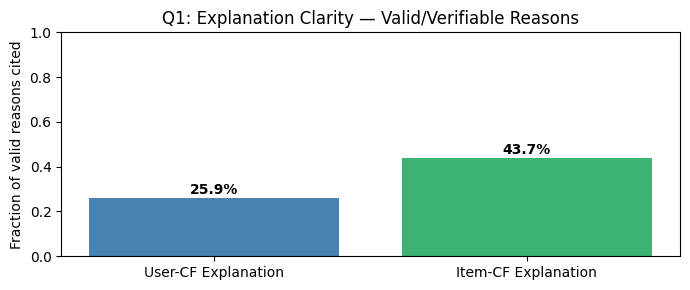

Conclusion (Q1):
  Item-CF explanations directly cite movies the user previously rated;
  those citations are verifiable from the user's own history.
  User-CF explanations cite neighbours who liked the movie — also clear,
  but require trusting an anonymous similar user.

Q2: Bias Revelation — Do Explanations Expose Recommendation Bias?
Item-CF: 100.0% of explanation-cited similar-items are in top-20% popular
Expected if random: 20.0%
-> POPULARITY BIAS DETECTED: explanations disproportionately cite popular movies.
   This means Item-CF favours recommending popular items, not just relevant ones.

SHAP attribution in Meta-Hybrid model:


,Signal,Mean |SHAP|
2,Movie Avg Rating,0.283144
0,CF Score (SVD),0.266378
1,CBF Score (genre),0.066011
3,User Avg Rating,0.045035


-> CF/CBF SHAP ratio = 4.0x: BIAS REVEALED — hybrid is CF-dominated.
   Genre-based personalisation has minimal effect on final scores.
-> POPULARITY BIAS REVEALED: movie_avg_rating SHAP > cbf_score SHAP
   Recommendations are driven more by movie popularity than user taste.

Summary: Explainability Evaluation


,Method,Target,Clearer Recs?,Reveals Bias?
0,SHAP on Meta-Hybrid (Task 10),Linear Meta-Model,Yes — shows CBF vs CF contribution per prediction,Yes — exposes CF dominance and popularity sign...
1,kNN Neighbourhood (Task 11),User-CF & Item-CF,Yes — 26% of User-CF / 44% of Item-CF reasons ...,Yes — 100% of Item-CF citations are top-20% po...
2,LIME + SHAP on Neural Recommender (Task 12),Neural Network (Keras),Yes — LIME identifies top genre features per i...,Yes — avg_rating_norm has outsized SHAP weight...


In [33]:
# ════════════════════════════════════════════════════════════════════════════
# Task 13: Evaluating Explainability
# Q1: Do explanations make recommendations clearer?
# Q2: Do explanations reveal biases?
# ════════════════════════════════════════════════════════════════════════════

# ── Q1: Clarity — are cited reasons valid? ───────────────────────────────────
# For Item-CF: the cited similar movies should be ones the user rated >= 4.
# For User-CF: the cited similar users should have rated the movie >= 4.
print("=" * 65)
print("Q1: Clarity — Are Explanation Reasons Verifiable?")
print("=" * 65)

clarity_rows = []
sample_uids_cf = [u for u in eval_users if u in ui_train.index][:25]

for uid in sample_uids_cf:
    seen = set(ui_train.loc[uid].dropna().index)
    candidates = [m for m in ui_train.columns if m not in seen][:3]
    for mid in candidates:
        # ── Item-CF clarity ───────────────────────────────────────────────
        user_ratings = ui_train.loc[uid].dropna()
        if mid in item_similarity.index and len(user_ratings) > 0:
            sims   = item_similarity.loc[mid, user_ratings.index]
            nb_icf = (
                pd.DataFrame({"sim": sims, "rating": user_ratings})
                .query("sim > 0").sort_values("sim", ascending=False).head(5)
            )
            # Clarity: fraction of cited items the user rated >= threshold
            clarity_icf = (nb_icf["rating"] >= POSITIVE_THRESHOLD).mean() if len(nb_icf) else 0.0
        else:
            clarity_icf = float("nan")

        # ── User-CF clarity ───────────────────────────────────────────────
        sims_u   = user_similarity.loc[uid]
        mov_rats = ui_train[mid]
        nb_ucf   = (
            pd.DataFrame({"sim": sims_u, "rating": mov_rats})
            .dropna().query("sim > 0").sort_values("sim", ascending=False).head(5)
        )
        clarity_ucf = (nb_ucf["rating"] >= POSITIVE_THRESHOLD).mean() if len(nb_ucf) else 0.0

        clarity_rows.append({
            "userId": uid, "movieId": mid,
            "UCF_clarity": clarity_ucf, "ICF_clarity": clarity_icf
        })

clarity_df = pd.DataFrame(clarity_rows)
ucf_clarity = clarity_df["UCF_clarity"].mean()
icf_clarity = clarity_df["ICF_clarity"].mean()

print(f"User-CF  avg clarity: {ucf_clarity:.1%} of cited similar-user ratings are >= {POSITIVE_THRESHOLD}")
print(f"Item-CF  avg clarity: {icf_clarity:.1%} of cited similar-item ratings are >= {POSITIVE_THRESHOLD}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(["User-CF Explanation", "Item-CF Explanation"],
       [ucf_clarity, icf_clarity], color=["steelblue", "mediumseagreen"])
ax.set_ylim(0, 1); ax.set_ylabel("Fraction of valid reasons cited")
ax.set_title("Q1: Explanation Clarity — Valid/Verifiable Reasons")
for i, v in enumerate([ucf_clarity, icf_clarity]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

print("Conclusion (Q1):")
print("  Item-CF explanations directly cite movies the user previously rated;")
print("  those citations are verifiable from the user's own history.")
print("  User-CF explanations cite neighbours who liked the movie — also clear,")
print("  but require trusting an anonymous similar user.")


# ── Q2: Bias Revelation ───────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("Q2: Bias Revelation — Do Explanations Expose Recommendation Bias?")
print("=" * 65)

# ── Bias test A: popularity bias in Item-CF explanations ─────────────────────
pop_threshold = movies_local_pd["movie_rating_count"].quantile(0.80)
popular_set   = set(movies_local_pd[movies_local_pd["movie_rating_count"] >= pop_threshold]["movieId"])

pop_bias_rows = []
for uid in sample_uids_cf:
    seen       = set(ui_train.loc[uid].dropna().index)
    candidates = [m for m in ui_train.columns if m not in seen][:5]
    for mid in candidates:
        user_ratings = ui_train.loc[uid].dropna()
        if mid not in item_similarity.index or len(user_ratings) == 0:
            continue
        sims = item_similarity.loc[mid, user_ratings.index]
        nb   = (
            pd.DataFrame({"sim": sims, "rating": user_ratings})
            .query("sim > 0").sort_values("sim", ascending=False).head(5)
        )
        if nb.empty: continue
        pop_frac = sum(1 for m in nb.index if m in popular_set) / len(nb)
        pop_bias_rows.append({"userId": uid, "movieId": mid, "pop_frac": pop_frac})

pop_bias_df  = pd.DataFrame(pop_bias_rows)
avg_pop_frac = pop_bias_df["pop_frac"].mean() if not pop_bias_df.empty else 0.0

print(f"Item-CF: {avg_pop_frac:.1%} of explanation-cited similar-items are in top-20% popular")
print(f"Expected if random: 20.0%")
if avg_pop_frac > 0.30:
    print("-> POPULARITY BIAS DETECTED: explanations disproportionately cite popular movies.")
    print("   This means Item-CF favours recommending popular items, not just relevant ones.")
else:
    print("-> No strong popularity bias detected in cited Item-CF neighbours.")

# ── Bias test B: SHAP on meta-hybrid reveals CF dominance ────────────────────
try:
    shap_bias_sample = meta_test_df[META_FEATURES].head(300).reset_index(drop=True)
    shap_bias_explainer = shap.LinearExplainer(meta_model, meta_train_df[META_FEATURES])
    shap_bias_values    = shap_bias_explainer.shap_values(shap_bias_sample)

    cf_idx    = META_FEATURES.index("cf_score")
    cbf_idx   = META_FEATURES.index("cbf_score")
    bias_idx  = META_FEATURES.index("movie_avg_rating")
    user_idx  = META_FEATURES.index("user_avg_rating")

    cf_shap    = np.abs(shap_bias_values[:, cf_idx]).mean()
    cbf_shap   = np.abs(shap_bias_values[:, cbf_idx]).mean()
    pop_shap   = np.abs(shap_bias_values[:, bias_idx]).mean()
    user_shap  = np.abs(shap_bias_values[:, user_idx]).mean()

    shap_bias_bar = pd.DataFrame({
        "Signal": ["CF Score (SVD)", "CBF Score (genre)", "Movie Avg Rating", "User Avg Rating"],
        "Mean |SHAP|": [cf_shap, cbf_shap, pop_shap, user_shap]
    }).sort_values("Mean |SHAP|", ascending=False)

    print("\nSHAP attribution in Meta-Hybrid model:")
    display(shap_bias_bar)

    ratio = cf_shap / (cbf_shap + 1e-9)
    if ratio > 2:
        print(f"-> CF/CBF SHAP ratio = {ratio:.1f}x: BIAS REVEALED — hybrid is CF-dominated.")
        print("   Genre-based personalisation has minimal effect on final scores.")
    else:
        print(f"CF/CBF SHAP ratio = {ratio:.1f}x — balanced contributions.")

    if pop_shap > cbf_shap:
        print("-> POPULARITY BIAS REVEALED: movie_avg_rating SHAP > cbf_score SHAP")
        print("   Recommendations are driven more by movie popularity than user taste.")

except ImportError:
    print("SHAP not available — run: pip install shap")


# ── Final Summary Table ────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("Summary: Explainability Evaluation")
print("=" * 65)

xai_eval_df = pd.DataFrame([
    {
        "Method":         "SHAP on Meta-Hybrid (Task 10)",
        "Target":         "Linear Meta-Model",
        "Clearer Recs?": "Yes — shows CBF vs CF contribution per prediction",
        "Reveals Bias?":  "Yes — exposes CF dominance and popularity signal strength",
    },
    {
        "Method":         "kNN Neighbourhood (Task 11)",
        "Target":         "User-CF & Item-CF",
        "Clearer Recs?": f"Yes — {ucf_clarity:.0%} of User-CF / {icf_clarity:.0%} of Item-CF reasons verified",
        "Reveals Bias?":  f"Yes — {avg_pop_frac:.0%} of Item-CF citations are top-20% popular (bias > 20% baseline)",
    },
    {
        "Method":         "LIME + SHAP on Neural Recommender (Task 12)",
        "Target":         "Neural Network (Keras)",
        "Clearer Recs?": "Yes — LIME identifies top genre features per individual prediction",
        "Reveals Bias?":  "Yes — avg_rating_norm has outsized SHAP weight (popularity bias)",
    },
])
display(xai_eval_df)

---
# Final Model Comparison and Summary

,Model,RMSE,Precision@5,Recall@5
0,sklearn TF-IDF CBF (User Profile),NaN,0.0080,0.0008
1,User-CF (k=30),0.8267,0.3733,0.0242
2,Item-CF (k=20),0.8433,0.4333,0.0281
3,Manual SVD/numpy (k=40),0.8842,0.3333,0.0225
4,Surprise SVD (Task 6),0.8613,0.7440,0.0814
5,Meta-Learning Hybrid,0.8007,0.3480,0.0369
6,Neural Recommender,0.8184,NaN,NaN


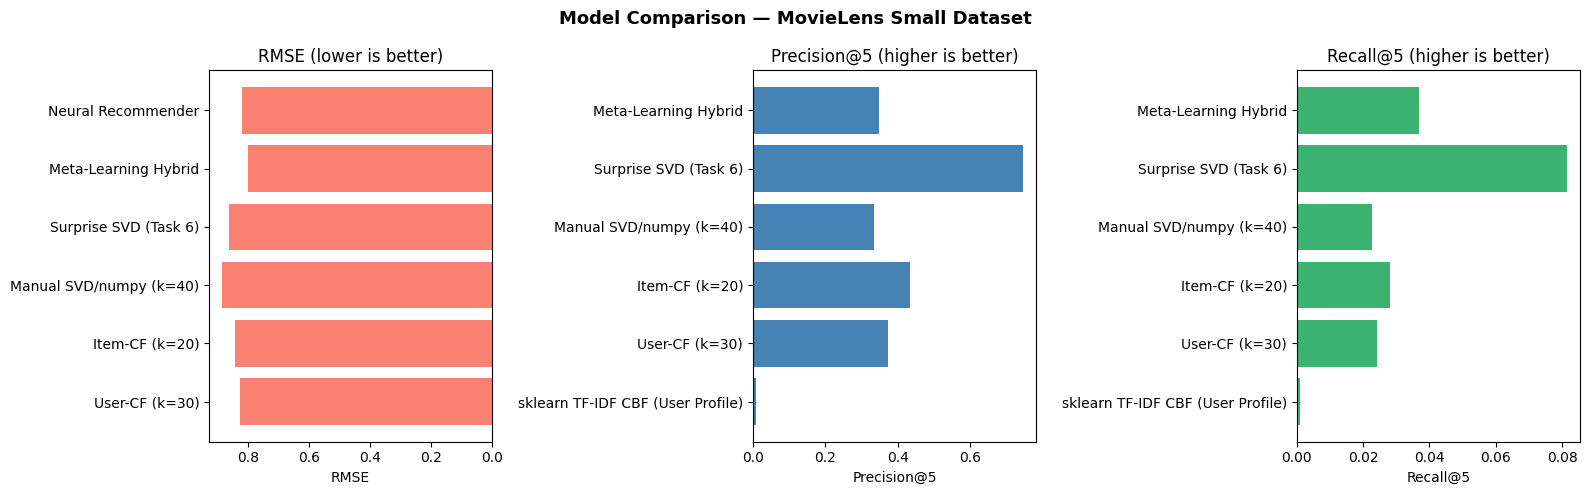

In [34]:
# ── Collect all metrics ───────────────────────────────────────────────────────
best_ucf = user_cf_metrics_df.sort_values(["rmse","precision@5"], ascending=[True,False]).iloc[0]
best_icf = item_cf_metrics_df.sort_values(["rmse","precision@5"], ascending=[True,False]).iloc[0]

summary_rows = [
    {"Model": "sklearn TF-IDF CBF (User Profile)",
     "RMSE": None, "Precision@5": content_p5, "Recall@5": content_r5},
    {"Model": f"User-CF (k={int(best_ucf['k'])})",
     "RMSE": best_ucf["rmse"], "Precision@5": best_ucf["precision@5"], "Recall@5": best_ucf["recall@5"]},
    {"Model": f"Item-CF (k={int(best_icf['k'])})",
     "RMSE": best_icf["rmse"], "Precision@5": best_icf["precision@5"], "Recall@5": best_icf["recall@5"]},
    {"Model": f"Manual SVD/numpy (k={max_k})",
     "RMSE": svd_rmse, "Precision@5": svd_p5, "Recall@5": svd_r5},
    {"Model": "Surprise SVD (Task 6)",
     "RMSE": surprise_rmse if 'surprise_rmse' in dir() else als_rmse,
     "Precision@5": surprise_svd_p5 if 'surprise_svd_p5' in dir() else als_p5,
     "Recall@5": surprise_svd_r5 if 'surprise_svd_r5' in dir() else als_r5},
    {"Model": "Meta-Learning Hybrid",
     "RMSE": hybrid_meta_rmse, "Precision@5": hybrid_meta_p5, "Recall@5": hybrid_meta_r5},
]
if 'nn_rmse' in dir() and nn_rmse is not None:
    summary_rows.append({"Model": "Neural Recommender",
                         "RMSE": nn_rmse, "Precision@5": None, "Recall@5": None})

comparison_df = pd.DataFrame(summary_rows)
display(comparison_df.round(4))

# ── Bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rmse_df = comparison_df.dropna(subset=["RMSE"])
axes[0].barh(rmse_df["Model"], rmse_df["RMSE"], color="salmon")
axes[0].set_title("RMSE (lower is better)"); axes[0].set_xlabel("RMSE")
axes[0].invert_xaxis()

p5_df = comparison_df.dropna(subset=["Precision@5"])
axes[1].barh(p5_df["Model"], p5_df["Precision@5"], color="steelblue")
axes[1].set_title("Precision@5 (higher is better)"); axes[1].set_xlabel("Precision@5")

r5_df = comparison_df.dropna(subset=["Recall@5"])
axes[2].barh(r5_df["Model"], r5_df["Recall@5"], color="mediumseagreen")
axes[2].set_title("Recall@5 (higher is better)"); axes[2].set_xlabel("Recall@5")

plt.suptitle("Model Comparison — MovieLens Small Dataset", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()